# MacSentinel 04 · GRU-Style Sequence Detection

## tl;dr

A deterministic GRU cell converts ordered six-event sessions into compact embeddings, and a learned logistic head classifies unseen hosts. The architecture exposes the sequence representation without requiring a heavyweight deep-learning runtime.

## Goal

Evaluate whether ordered event context improves detection beyond flat session features.

**Safety and scope:** all events are deterministic synthetic fixtures. Reserved `.example` domains and inert filenames are used; this project does not execute payloads, collect private data, or bypass platform controls.


## Setup

Load the shared synthetic macOS telemetry fixture and dependency-light visualization helpers. The data source and seed are explicit so every result can be reproduced offline.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

from macsentinel.core import *
from macsentinel.visuals import *

SEED = 42
DATA_PATH = Path("data/synthetic_macos_events.csv")
events = pd.read_csv(DATA_PATH, parse_dates=["timestamp"])
FIGURES = []
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

print(f"Loaded {len(events):,} synthetic events across {events.session_id.nunique():,} sessions and {events.host_id.nunique()} hosts.")


Loaded 2,520 synthetic events across 420 sessions and 30 hosts.


## Steps

### 1. Build ordered session tensors


In [2]:
sequence_tensor, sequence_labels, sequence_ids, sequence_features = make_sequence_tensor(events)
session_lookup = aggregate_sessions(events).set_index("session_id").loc[sequence_ids].reset_index()
train_index, test_index = group_train_test_split(session_lookup, test_fraction=0.30)
print(pd.Series({"sessions": len(sequence_ids), "steps": sequence_tensor.shape[1], "event_features": sequence_tensor.shape[2], "attack_rate": sequence_labels.mean()}).to_string())
print("Sequence features:", ", ".join(sequence_features))


sessions          420.000000
steps               6.000000
event_features      9.000000
attack_rate         0.178571
Sequence features: signed, notarized, gatekeeper_bypass, xprotect_detection, privilege_escalation, persistence_write, sensitive_access, network_beacon, command_risk


### 2. Encode each event stream with an inspectable GRU cell


In [3]:
gru_embeddings = gru_encode_sequences(sequence_tensor, hidden_size=12)
print(f"GRU embedding matrix: {gru_embeddings.shape[0]} sessions × {gru_embeddings.shape[1]} features")
print(pd.DataFrame(gru_embeddings[:4, :8]).round(3).to_string(index=False))


GRU embedding matrix: 420 sessions × 36 features
     0      1      2     3      4      5      6      7
 0.335  0.520 -0.238 0.044  0.314 -0.542 -0.339 -0.075
-0.103 -0.129  0.159 0.093 -0.027  0.050  0.060 -0.021
-0.126 -0.097  0.097 0.126  0.004  0.019  0.017 -0.047
-0.125 -0.104  0.107 0.120 -0.001  0.028  0.027 -0.040


### 3. Learn and evaluate a lightweight detection head


In [4]:
embedding_names = [f"gru_{index:02d}" for index in range(gru_embeddings.shape[1])]
gru_head = fit_logistic(gru_embeddings[train_index], sequence_labels[train_index], embedding_names, steps=2200)
gru_scores = predict_logistic(gru_head, gru_embeddings[test_index])
gru_metrics = evaluate_scores(sequence_labels[test_index], gru_scores, 0.50)

flat_features = session_lookup[FEATURE_COLUMNS].to_numpy()
flat_model = fit_logistic(flat_features[train_index], sequence_labels[train_index], FEATURE_COLUMNS)
flat_scores = predict_logistic(flat_model, flat_features[test_index])
flat_metrics = evaluate_scores(sequence_labels[test_index], flat_scores, 0.50)
comparison = pd.DataFrame([flat_metrics, gru_metrics], index=["flat logistic", "GRU encoder + logistic head"])
print(comparison[["precision", "recall", "f1", "average_precision", "alert_rate"]].round(3).to_string())


                             precision  recall     f1  average_precision  alert_rate
flat logistic                      0.7   0.955  0.808              0.969       0.244
GRU encoder + logistic head        1.0   0.955  0.977              0.964       0.171


## Visual Insights & ML Extension

### 4. Inspect the learned sequence representation


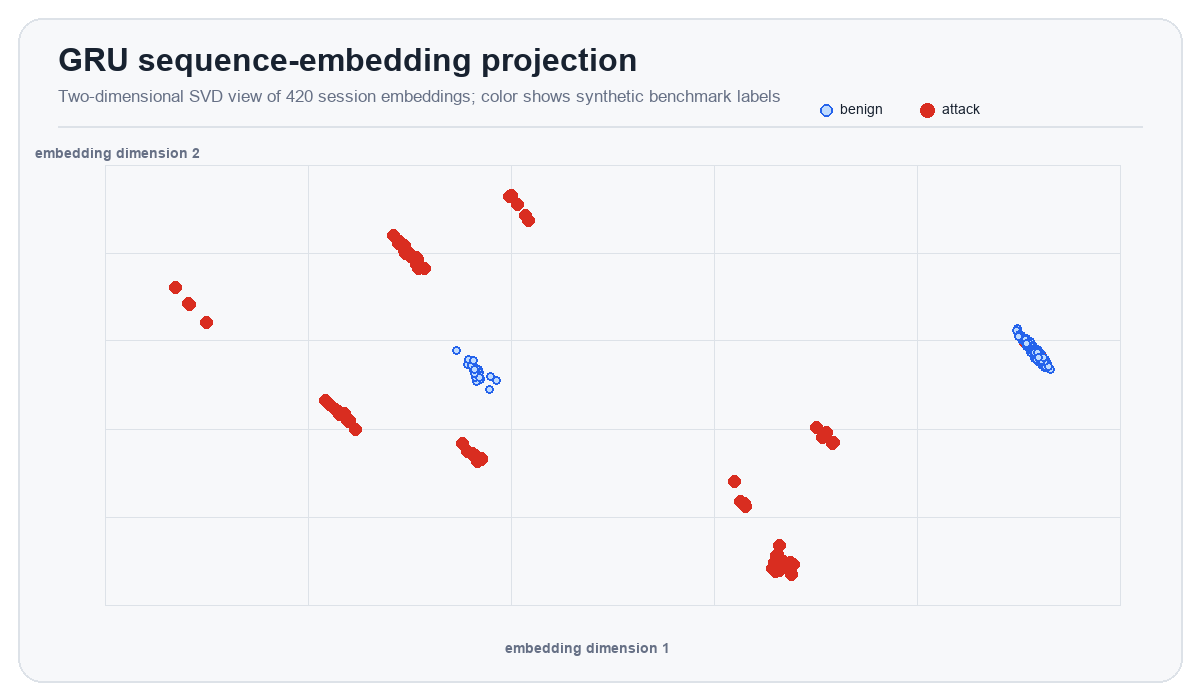

In [5]:
standardized = (gru_embeddings - gru_embeddings.mean(axis=0)) / np.where(gru_embeddings.std(axis=0) < 1e-6, 1, gru_embeddings.std(axis=0))
_, _, components = np.linalg.svd(standardized, full_matrices=False)
projection = standardized @ components[:2].T
figure = scatter_chart(
    projection[:, 0], projection[:, 1], sequence_labels,
    "GRU sequence-embedding projection",
    "Two-dimensional SVD view of 420 session embeddings; color shows synthetic benchmark labels",
    "embedding dimension 1", "embedding dimension 2",
)
FIGURES.append(figure)
figure


### 5. Compare scenario recall


scenario
ransomware_burst           0.667
credential_access          1.000
data_exfiltration          1.000
download_execute           1.000
gatekeeper_bypass          1.000
launchagent_persistence    1.000


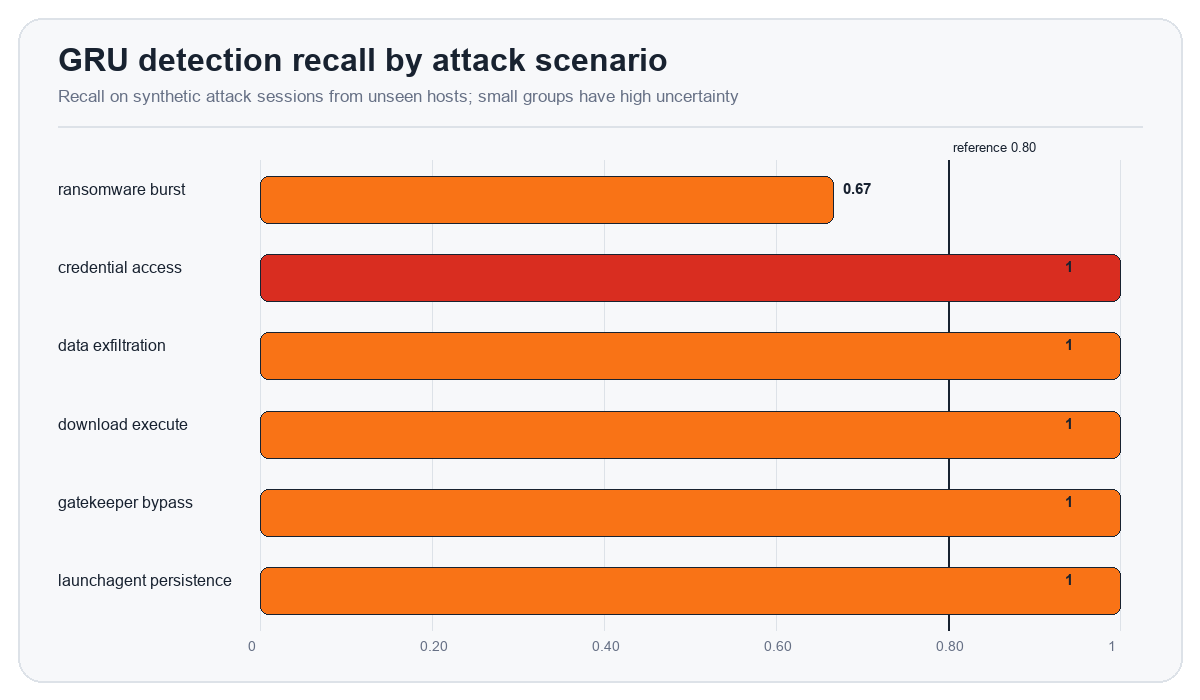

In [6]:
test_results = session_lookup.iloc[test_index][["session_id", "scenario", "label"]].copy()
test_results["detected"] = (gru_scores >= 0.50).astype(int)
scenario_recall = test_results[test_results.label.eq(1)].groupby("scenario").detected.mean().sort_values()
print(scenario_recall.round(3).to_string())
figure = bar_chart(
    scenario_recall.index,
    scenario_recall.values,
    "GRU detection recall by attack scenario",
    "Recall on synthetic attack sessions from unseen hosts; small groups have high uncertainty",
    color=ORANGE,
    benchmark=0.80,
)
FIGURES.append(figure)
figure


## Checks


In [7]:
assert sequence_tensor.shape[:2] == (events.session_id.nunique(), 6)
assert session_lookup.iloc[train_index].host_id.isin(session_lookup.iloc[test_index].host_id).sum() == 0
assert np.isfinite(gru_embeddings).all()
assert gru_metrics["average_precision"] > sequence_labels[test_index].mean()
print("PASS: sequence shape, host separation, finite embeddings, and lift over prevalence are valid.")


PASS: sequence shape, host separation, finite embeddings, and lift over prevalence are valid.


## Next Steps

- Replace the fixed educational encoder with a trained GRU in PyTorch or MLX.
- Benchmark quantized inference latency and memory on Apple silicon.
- Add sequence explanations that identify which event transition changed the alert score.
